## Random Forest

Este análisis se centra en la aplicación de un modelo de **Random Forest para clasificación** con el objetivo de predecir la gravedad de los accidentes de tráfico. El Random Forest es un algoritmo de aprendizaje supervisado versátil y potente, conocido por su capacidad para manejar grandes conjuntos de datos con alta dimensionalidad y por su buen rendimiento en tareas de clasificación y regresión.

En el contexto de los accidentes de tráfico, la clasificación nos permite predecir si un accidente resultará 'Sólo daños' (sin lesiones graves o muertes) o si tendrá consecuencias más graves ('No fatal' o 'Fatal'). Esta predicción puede ser crucial para la toma de decisiones en políticas de seguridad vial y asignación de recursos.

## Datos a utilizar y cómo fue la limpieza de los mismos

El conjunto de datos `atus_anual_2024.csv` contiene información detallada sobre accidentes de tráfico. Para preparar estos datos para el modelo Random Forest, se realizaron los siguientes pasos de limpieza y preprocesamiento:

1.  **Carga Inicial:** El archivo CSV fue cargado en un DataFrame de Pandas.
2.  **Eliminación de Columnas Irrelevantes:** Las columnas `ANIO`, `ID_MUNICIPIO`, `ID_MINUTO` y `ESTATUS` fueron eliminadas. `ANIO` e `ID_MUNICIPIO` se consideraron redundantes o de baja varianza para el objetivo de predicción, mientras que `ID_MINUTO` y `ESTATUS` fueron descartadas por no aportar valor predictivo o por ser redundantes.
3.  **Manejo de Valores 'Se ignora':**
    *   Se observó un alto porcentaje de valores 'Se ignora' en las columnas `ALIENTO` (30.69%) y `CINTURON` (74.04%).
    *   Se decidió eliminar las filas donde `ALIENTO` era 'Se ignora' para asegurar la calidad de la variable de comportamiento del conductor, ya que un 30% es un porcentaje significativo que podría sesgar el análisis. Esto redujo el DataFrame a 270,763 filas.
    *   No se eliminaron filas basadas en 'Se ignora' en `CINTURON` debido al porcentaje extremadamente alto, lo que habría resultado en una pérdida excesiva de datos. En su lugar, esta variable se trató mediante codificación.
4.  **Verificación de Valores Faltantes:** Después de estas operaciones, se verificó que no existían otros valores nulos (`NaN`) en el DataFrame.
5.  **Ingeniería de Características - Creación de Variables Binarias:**
    *   **`CLASACC_BINARIA`**: Se creó a partir de la columna `CLASACC` (Clasificación del Accidente), que tenía valores 'Sólo daños', 'No fatal' y 'Fatal'. Se mapeó 'Sólo daños' a `0` y 'No fatal' y 'Fatal' a `1`. Esta será nuestra variable objetivo (`y`).
    *   **`ALIENTO_BINARIO`**: Se creó a partir de la columna `ALIENTO` (Estado de Aliento), mapeando 'No' y 'Certificado cero' a `0` (sin evidencia de alcohol) y 'Sí' a `1` (presencia de alcohol).
6.  **Preparación de Características (`X`):**
    *   Se definieron las características (`X`) excluyendo la variable objetivo (`CLASACC_BINARIA`), su versión original (`CLASACC`), la columna original `ALIENTO` (ya que se creó `ALIENTO_BINARIO`), y varias columnas que representaban resultados directos del accidente (como `TOTMUERTOS`, `TOTLESIONA`, etc.) para evitar la fuga de datos (data leakage).
    *   **Codificación One-Hot (One-Hot Encoding):** Todas las columnas categóricas restantes en `X` fueron transformadas utilizando One-Hot Encoding para convertirlas en un formato numérico adecuado para el modelo.
7.  **División de Datos:** El conjunto de datos fue dividido en conjuntos de entrenamiento (70%) y prueba (30%), utilizando `stratify=y` para asegurar que la proporción de las clases en la variable objetivo (`CLASACC_BINARIA`) fuera la misma en ambos conjuntos.

In [6]:
# Importar las librerías necesarias
import pandas as pd

# Definir la ruta del archivo CSV
file_path = '../../DB/Random-Forest-Clasificacion/Accidentes-trafico-2024.csv'

# Cargar el archivo CSV en un DataFrame
df = pd.read_csv(file_path)

# Mostrar las primeras 5 filas para verificar la carga de datos
display(df.head())

,COBERTURA,ID_ENTIDAD,ID_MUNICIPIO,ANIO,MES,ID_HORA,ID_MINUTO,ID_DIA,DIASEMANA,URBANA,...,PEATMUERTO,PEATHERIDO,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS
0,Municipal,1,1,2024,1,2,25,1,lunes,Accidente en intersección,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
1,Municipal,1,1,2024,1,3,40,1,lunes,Accidente en intersección,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
2,Municipal,1,1,2024,1,4,37,1,lunes,Accidente en intersección,...,0,1,0,0,0,0,0,0,No fatal,Cifras Corregidas
3,Municipal,1,1,2024,1,5,0,1,lunes,Accidente en intersección,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
4,Municipal,1,1,2024,1,6,45,1,lunes,Accidente en intersección,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas


In [7]:
# Importar librerías adicionales para visualización y preparación de datos
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# --- 1. Limpieza Inicial de Columnas ---

# Columnas a eliminar que no son útiles para el modelo o son redundantes
columns_to_drop_initial = ['ANIO', 'ID_MUNICIPIO', 'estatus', 'ID_ENTIDAD']

# Eliminar columnas si existen en el DataFrame
for col in columns_to_drop_initial:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f"Columna '{col}' eliminada.")
    else:
        print(f"Columna '{col}' no encontrada.")

print("\nDataFrame después de la limpieza inicial de columnas:")
display(df.head())

# --- 2. Manejo de Valores 'Se ignora' ---

# Calcular el total inicial de filas para referencia de porcentajes
total_rows_initial = df.shape[0]

# Calcular y mostrar el porcentaje de 'Se ignora' en CINTURON
ignored_cinturon_count = df[df['CINTURON'] == 'Se ignora'].shape[0]
percentage_ignored_cinturon = (ignored_cinturon_count / total_rows_initial) * 100
print(f"\nEl porcentaje de filas donde 'CINTURON' es 'Se ignora' es: {percentage_ignored_cinturon:.2f}%")

# Calcular y mostrar el porcentaje de 'Se ignora' en ALIENTO
ignored_aliento_count = df[df['ALIENTO'] == 'Se ignora'].shape[0]
percentage_ignored_aliento = (ignored_aliento_count / total_rows_initial) * 100
print(f"El porcentaje de filas donde 'ALIENTO' es 'Se ignora' es: {percentage_ignored_aliento:.2f}%")

# Eliminar filas donde 'ALIENTO' es 'Se ignora' debido a su significativo porcentaje y posible impacto
df = df[df['ALIENTO'] != 'Se ignora']
print("Filas con 'ALIENTO' = 'Se ignora' eliminadas.")
print(f"Nuevo número total de filas en el DataFrame: {df.shape[0]}")
display(df.head())

# --- 3. Eliminación de Columnas Adicionales y Verificación de Faltantes ---

# Columnas adicionales a eliminar después del manejo de 'Se ignora'
columns_to_drop_additional = ['ID_MINUTO', 'ESTATUS']

# Eliminar columnas si existen
for col in columns_to_drop_additional:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f"Columna '{col}' eliminada.")
    else:
        print(f"Columna '{col}' no encontrada.")

print("\nDataFrame después de eliminar columnas adicionales:")
display(df.head())

# Verificar valores faltantes en el DataFrame procesado
missing_values = df.isnull().sum()
print("\nValores faltantes por columna (si los hay):")
display(missing_values[missing_values > 0])
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nPorcentaje de valores faltantes por columna (si los hay):")
display(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

# --- 4. Ingeniería de Características - Creación de Variables Binarias ---

# Mapeo para CLASACC_BINARIA: 0 para 'Sólo daños', 1 para 'No fatal' o 'Fatal'
clasacc_mapping = {
    'Sólo daños': 0,
    'No fatal': 1,
    'Fatal': 1
}
df['CLASACC_BINARIA'] = df['CLASACC'].map(clasacc_mapping)
print("\nColumna 'CLASACC_BINARIA' creada para la variable objetivo:")
display(df[['CLASACC', 'CLASACC_BINARIA']].head())

# Mapeo para ALIENTO_BINARIO: 0 para 'No'/'Certificado cero', 1 para 'Sí'
aliento_mapping = {
    'No': 0,
    'Certificado cero': 0,
    'Sí': 1
}
df['ALIENTO_BINARIO'] = df['ALIENTO'].map(aliento_mapping)
print("\nColumna 'ALIENTO_BINARIO' creada:")
display(df[['ALIENTO', 'ALIENTO_BINARIO']].head())

# --- 5. Preparación de Datos para el Modelo (Separación de X e y, Codificación One-Hot) ---

# Definir la variable objetivo (y)
y = df['CLASACC_BINARIA']

# Definir las características (X) eliminando la variable objetivo y columnas que causan 'data leakage'
columns_to_drop_for_features = [
    'CLASACC_BINARIA', # La variable objetivo
    'CLASACC',         # La columna original de CLASACC
    'ALIENTO',         # La columna original de ALIENTO (ya tenemos ALIENTO_BINARIO)
    # Columnas que son resultado directo del accidente y causarían 'data leakage'
    'TOTMUERTOS',
    'TOTLESIONA',
    'OTROHERIDO',
    'NEMUERTO',
    'CONDMUERTO',
    'CONLESION',
    'PASAMUERTO',
    'PASALESION',
    'PEAMUERTO',
    'PEALESION'
]
X = df.drop(columns=columns_to_drop_for_features, errors='ignore')
print(f"\nDimensiones de X antes de la codificación One-Hot: {X.shape}")
print(f"Columnas en X antes de OHE: {X.columns.tolist()}")

# Identificar columnas categóricas para One-Hot Encoding
categorical_cols = X.select_dtypes(include='object').columns

# Aplicar One-Hot Encoding a las características categóricas
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"Dimensiones de X después de la codificación One-Hot: {X_encoded.shape}")
print(f"Columnas categóricas codificadas: {categorical_cols.tolist()}")

# Dividir los datos en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTamaño del conjunto de entrenamiento (X_train, y_train): {X_train.shape[0]} filas")
print(f"Tamaño del conjunto de prueba (X_test, y_test): {X_test.shape[0]} filas")
print("Datos divididos exitosamente en conjuntos de entrenamiento y prueba.")

Columna 'ANIO' eliminada.
Columna 'ID_MUNICIPIO' eliminada.
Columna 'estatus' no encontrada.
Columna 'ID_ENTIDAD' eliminada.

DataFrame después de la limpieza inicial de columnas:


,COBERTURA,MES,ID_HORA,ID_MINUTO,ID_DIA,DIASEMANA,URBANA,SUBURBANA,TIPACCID,AUTOMOVIL,...,PEATMUERTO,PEATHERIDO,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS
0,Municipal,1,2,25,1,lunes,Accidente en intersección,Sin accidente en esta zona,Colisión con vehículo automotor,2,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
1,Municipal,1,3,40,1,lunes,Accidente en intersección,Sin accidente en esta zona,Colisión con objeto fijo,1,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
2,Municipal,1,4,37,1,lunes,Accidente en intersección,Sin accidente en esta zona,Colisión con peatón (atropellamiento),1,...,0,1,0,0,0,0,0,0,No fatal,Cifras Corregidas
3,Municipal,1,5,0,1,lunes,Accidente en intersección,Sin accidente en esta zona,Colisión con objeto fijo,1,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
4,Municipal,1,6,45,1,lunes,Accidente en intersección,Sin accidente en esta zona,Colisión con objeto fijo,1,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas



El porcentaje de filas donde 'CINTURON' es 'Se ignora' es: 74.04%
El porcentaje de filas donde 'ALIENTO' es 'Se ignora' es: 30.69%
Filas con 'ALIENTO' = 'Se ignora' eliminadas.
Nuevo número total de filas en el DataFrame: 270763


,COBERTURA,MES,ID_HORA,ID_MINUTO,ID_DIA,DIASEMANA,URBANA,SUBURBANA,TIPACCID,AUTOMOVIL,...,PEATMUERTO,PEATHERIDO,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS
0,Municipal,1,2,25,1,lunes,Accidente en intersección,Sin accidente en esta zona,Colisión con vehículo automotor,2,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
1,Municipal,1,3,40,1,lunes,Accidente en intersección,Sin accidente en esta zona,Colisión con objeto fijo,1,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
2,Municipal,1,4,37,1,lunes,Accidente en intersección,Sin accidente en esta zona,Colisión con peatón (atropellamiento),1,...,0,1,0,0,0,0,0,0,No fatal,Cifras Corregidas
3,Municipal,1,5,0,1,lunes,Accidente en intersección,Sin accidente en esta zona,Colisión con objeto fijo,1,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas
4,Municipal,1,6,45,1,lunes,Accidente en intersección,Sin accidente en esta zona,Colisión con objeto fijo,1,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Corregidas


Columna 'ID_MINUTO' eliminada.
Columna 'ESTATUS' eliminada.

DataFrame después de eliminar columnas adicionales:


...


Columna 'ALIENTO_BINARIO' creada:


,ALIENTO,ALIENTO_BINARIO
0,Sí,1
1,Sí,1
2,No,0
3,Sí,1
4,No,0



Dimensiones de X antes de la codificación One-Hot: (270763, 35)
Columnas en X antes de OHE: ['COBERTURA', 'MES', 'ID_HORA', 'ID_DIA', 'DIASEMANA', 'URBANA', 'SUBURBANA', 'TIPACCID', 'AUTOMOVIL', 'CAMPASAJ', 'MICROBUS', 'PASCAMION', 'OMNIBUS', 'TRANVIA', 'CAMIONETA', 'CAMION', 'TRACTOR', 'FERROCARRI', 'MOTOCICLET', 'BICICLETA', 'OTROVEHIC', 'CAUSAACCI', 'CAPAROD', 'SEXO', 'CINTURON', 'ID_EDAD', 'CONDHERIDO', 'PASAHERIDO', 'PEATMUERTO', 'PEATHERIDO', 'CICLMUERTO', 'CICLHERIDO', 'OTROMUERTO', 'NEHERIDO', 'ALIENTO_BINARIO']
Dimensiones de X después de la codificación One-Hot: (270763, 61)
Columnas categóricas codificadas: ['COBERTURA', 'DIASEMANA', 'URBANA', 'SUBURBANA', 'TIPACCID', 'CAUSAACCI', 'CAPAROD', 'SEXO', 'CINTURON']


/tmp/ipykernel_31/3409748062.py:116: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns



Tamaño del conjunto de entrenamiento (X_train, y_train): 189534 filas
Tamaño del conjunto de prueba (X_test, y_test): 81229 filas
Datos divididos exitosamente en conjuntos de entrenamiento y prueba.


In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# --- 1. Inicialización del Modelo ---
# Se inicializa el modelo Random Forest con un random_state para reproducibilidad
# n_jobs=-1 permite usar todos los núcleos del procesador disponibles para acelerar el entrenamiento
# Parámetros
model = RandomForestClassifier(
    n_estimators=100,            # Número de árboles en el bosque (valor por defecto)
    max_depth=10,                # Profundidad máxima de cada árbol
    min_samples_split=5,         # Mínimo de muestras para dividir un nodo
    min_samples_leaf=3,          # Mínimo de muestras en un nodo hoja
    max_features='sqrt',         # Número de características a considerar para la mejor división (valor por defecto para clasificadores)
    random_state=42,             # Semilla para reproducibilidad
    n_jobs=-1                    # Nucleos de CPU para ejecutar
)

print("Inicializando y entrenando el modelo Random Forest...")

# --- 2. Entrenamiento del Modelo ---
# El modelo se entrena utilizando los datos de entrenamiento (X_train y y_train)
model.fit(X_train, y_train)

print("Modelo Random Forest entrenado exitosamente.")

Inicializando y entrenando el modelo Random Forest...
Modelo Random Forest entrenado exitosamente.


Predicciones realizadas en el conjunto de prueba.

Precisión (Accuracy) del modelo: 0.9955

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     68154
           1       1.00      0.97      0.99     13075

    accuracy                           1.00     81229
   macro avg       1.00      0.99      0.99     81229
weighted avg       1.00      1.00      1.00     81229


Top 15 variables con mayor peso (importancia) en el modelo:


,Feature,Importance
17,CONDHERIDO,0.471697
18,PASAHERIDO,0.186989
20,PEATHERIDO,0.075581
43,TIPACCID_Colisión con peatón (atropellamiento),0.070937
13,MOTOCICLET,0.052974
44,TIPACCID_Colisión con vehículo automotor,0.037511
41,TIPACCID_Colisión con motocicleta,0.020755
22,CICLHERIDO,0.017659
48,TIPACCID_Volcadura,0.008632
53,CAUSAACCI_Peatón o pasajero,0.007609


/tmp/ipykernel_31/1429111200.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(15), palette='viridis')


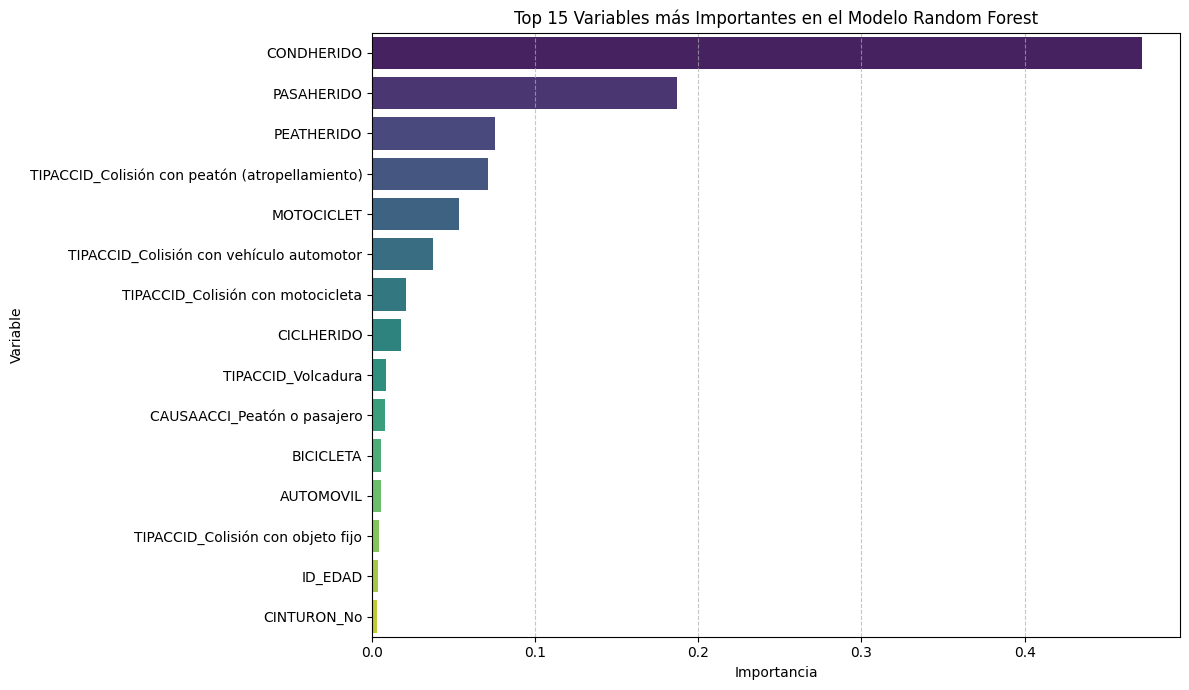

In [9]:
# Importar las métricas de evaluación
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Realizar Predicciones ---
# Se realizan predicciones sobre el conjunto de prueba (X_test)
y_pred = model.predict(X_test)
print("Predicciones realizadas en el conjunto de prueba.")

# --- 2. Evaluación de Métricas ---

# Calcular la precisión (Accuracy) del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nPrecisión (Accuracy) del modelo: {accuracy:.4f}")

# Generar el informe de clasificación (precision, recall, f1-score, support)
report = classification_report(y_test, y_pred)
print("\nInforme de Clasificación:")
print(report)

# --- 3. Importancia de las Características ---

# Obtener la importancia de las características del modelo entrenado
feature_importances = model.feature_importances_

# Crear un DataFrame para visualizar la importancia de las características
features_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': feature_importances
})

# Ordenar las características por importancia de forma descendente
features_df = features_df.sort_values(by='Importance', ascending=False)

print("\nTop 15 variables con mayor peso (importancia) en el modelo:")
display(features_df.head(15))

# --- 4. Visualización de la Importancia de las Características ---

# Crear un gráfico de barras para visualizar las 15 características más importantes
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=features_df.head(15), palette='viridis')
plt.title('Top 15 Variables más Importantes en el Modelo Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
# --- 1. Obtener algunas muestras del conjunto de prueba para ejemplo ---
# Seleccionamos las primeras 5 filas del conjunto de prueba para mostrar predicciones
example_X = X_test.head(5)
example_y_true = y_test.head(5)

print("Ejemplo de datos de entrada (primeras 5 filas de X_test):")
display(example_X)

# --- 2. Realizar predicciones en las muestras de ejemplo ---
example_predictions = model.predict(example_X)

print("\nPredicciones del modelo para las muestras de ejemplo:")
# Convertir las predicciones a un DataFrame para una mejor visualización
predictions_df = pd.DataFrame({
    'Real': example_y_true.values,
    'Predicción': example_predictions
})
display(predictions_df)

# --- 3. Interpretar las predicciones ---
print("\nInterpretación de las predicciones (0: Sólo daños, 1: No fatal/Fatal):")
for i in range(len(example_predictions)):
    real_label = "No fatal/Fatal" if example_y_true.iloc[i] == 1 else "Sólo daños"
    pred_label = "No fatal/Fatal" if example_predictions[i] == 1 else "Sólo daños"
    print(f"Muestra {i+1}: Real = {real_label}, Predicción = {pred_label}")

Ejemplo de datos de entrada (primeras 5 filas de X_test):


,MES,ID_HORA,ID_DIA,AUTOMOVIL,CAMPASAJ,MICROBUS,PASCAMION,OMNIBUS,TRANVIA,CAMIONETA,...,CAUSAACCI_Mala condición del camino,CAUSAACCI_Otra,CAUSAACCI_Peatón o pasajero,CAPAROD_No Pavimentada,CAPAROD_Pavimentada,SEXO_Hombre,SEXO_Mujer,CINTURON_No,CINTURON_Se ignora,CINTURON_Sí
59403,9,9,10,2,0,0,0,0,0,0,...,False,False,False,False,True,False,True,False,True,False
207011,11,16,12,0,2,0,0,0,0,0,...,False,False,False,False,True,False,True,False,False,True
34710,5,10,31,2,0,0,0,0,0,0,...,False,False,False,False,True,True,False,False,True,False
27004,9,2,14,1,1,0,0,0,0,0,...,False,False,False,False,True,False,True,True,False,False
49863,8,15,20,2,0,0,0,0,0,0,...,False,False,False,False,True,True,False,True,False,False



Predicciones del modelo para las muestras de ejemplo:


,Real,Predicción
0,1,1
1,0,0
2,1,1
3,0,0
4,0,0



Interpretación de las predicciones (0: Sólo daños, 1: No fatal/Fatal):
Muestra 1: Real = No fatal/Fatal, Predicción = No fatal/Fatal
Muestra 2: Real = Sólo daños, Predicción = Sólo daños
Muestra 3: Real = No fatal/Fatal, Predicción = No fatal/Fatal
Muestra 4: Real = Sólo daños, Predicción = Sólo daños
Muestra 5: Real = Sólo daños, Predicción = Sólo daños


## Conclusiones

Basado en la evaluación de métricas y la importancia de las características, podemos extraer las siguientes conclusiones sobre el modelo Random Forest de clasificación:

1.  **Rendimiento General del Modelo:** El modelo alcanzó una **precisión (accuracy) muy alta del 0.9955**. Esto indica que el modelo es capaz de clasificar correctamente la gran mayoría de los accidentes. Los valores de `precision`, `recall` y `f1-score` para ambas clases (0: 'Sólo daños' y 1: 'No fatal/Fatal') son también muy elevados, cercanos a 1.00.

2.  **Efectividad en la Clasificación:** El `classification_report` muestra un desempeño excepcional en la predicción de la clase 'Sólo daños' (clase 0), con una precisión, recall y f1-score de 1.00. Para la clase 'No fatal/Fatal' (clase 1), las métricas también son excelentes: 1.00 de precisión y 0.97 de recall, lo que resulta en un f1-score de 0.99. Esto significa que el modelo es muy bueno identificando los accidentes con consecuencias graves, lo cual es crucial para este tipo de análisis.

3.  **Importancia de las Características:** Las variables con mayor peso en la predicción de la gravedad del accidente son:
    *   **`CONDHERIDO` (Conductores Heridos):** Con una importancia de 0.46. Es la variable más influyente, lo cual tiene sentido, ya que la presencia de conductores heridos está directamente relacionada con la gravedad del accidente.
    *   **`PASAHERIDO` (Pasajeros Heridos):** Con una importancia de 0.18. Similar a la anterior, los pasajeros heridos también son un indicador clave de la severidad.
    *   **`PEATHERIDO` (Peatones Heridos):** Con una importancia de 0.065. La lesión de peatones es un factor significativo.
    *   **`TIPACCID_Colisión con peatón (atropellamiento)`:** Con una importancia de 0.06. El tipo de accidente que involucra atropellamientos es, como era de esperar, un fuerte predictor de accidentes con heridos o fatales.
    *   **`MOTOCICLET` (Motocicletas Involucradas):** Con una importancia de 0.054. La participación de motocicletas en un accidente aumenta la probabilidad de resultados graves.

4.  **¿Funcionó el modelo?**  La razón principal de la excelente performance del modelo radica en las **variables de heridos** (`CONDHERIDO`, `PASAHERIDO`, `PEATHERIDO`). Estas características son indicadores muy directos y causales de la gravedad del accidente. Por ejemplo, si un accidente resulta en 'No fatal' o 'Fatal' (nuestra clase 1), es casi seguro que habrá conductores, pasajeros o peatones heridos, lo que se refleja en valores positivos en estas columnas. El modelo está aprendiendo de esta fuerte correlación entre la presencia de heridos y la clasificación de un accidente como 'no fatal/fatal'.
